# 00 · The Synthetic Tasks — Data Inspection

Before any modelling, this notebook just **looks at the raw data** produced by `synthtasks/`. No models, no training, no GPU — only the generators, a printed worked example, and a picture of each task. The point is to make every task's encoding concrete so the comparison notebooks (`01+`) can be read with confidence.

Each generator returns the same triple — `(inputs, targets, mask)` — and **every metric scores only the `mask=True` positions**, so demonstration / filler / non-query tokens can never leak into a score.

## The three capabilities

| Task | Capability isolated | Difficulty knob(s) |
|---|---|---|
| **In-context linear regression** | infer an unseen linear map `y = Wx` from (x, y) demos held in state, then apply it to a fresh query | `n_examples` (evidence), `noise`, `drift` |
| **Multi-query associative recall (MQAR)** | write key→value bindings into state and read them back later | `n_pairs` (memory load), `gap` (retention distance) |
| **Running parity** | maintain one recurrent bit, updated every step and never decaying | `seq_len` (state-tracking horizon) |

All three are pure NumPy, fully seeded, and verified well-posed by `synthtasks/sanity.py`.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `synthtasks` importable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from synthtasks.regression import make_regression
from synthtasks.mqar import make_mqar
from synthtasks.parity import make_parity

np.set_printoptions(precision=3, suppress=True)
SEED = 0

## 1 · In-context linear regression

`D = d + 1` channels per token, interleaved:

- **even position `2i`** → x token `[x_i (d dims), 0]` — a **query** position (`mask=True`); the model must predict `y_i` here, *before* it is revealed.
- **odd position `2i+1`** → y token `[0 (d dims), y_i]` — reveals the answer one step later.

In the heatmap the first `d` channels light up on the x (even) columns and the last channel lights up on the y (odd) columns; the stem plot is the scalar target `y_i` at each scored query position.

In [2]:
d, n_examples = 4, 6
inputs, targets, mask = make_regression(
    batch=4, n_examples=n_examples, d=d, noise=0.0, drift=0.0, seed=SEED)

print(f"inputs {inputs.shape}  targets {targets.shape}  mask {mask.shape}   (token dim D = d+1 = {d+1})")
print("\nSequence for example 0  (last channel holds the scalar y):")
for t in range(inputs.shape[1]):
    kind = "x" if mask[0, t] else "y"
    note = f"  <- SCORED query, target y = {targets[0, t]:+.3f}" if mask[0, t] else ""
    print(f"  pos {t:2d} [{kind}]  token = {inputs[0, t]}{note}")

inputs (4, 12, 5)  targets (4, 12)  mask (4, 12)   (token dim D = d+1 = 5)

Sequence for example 0  (last channel holds the scalar y):
  pos  0 [x]  token = [ 0.126 -0.132  0.64   0.105  0.   ]  <- SCORED query, target y = -0.454
  pos  1 [y]  token = [ 0.     0.     0.     0.    -0.454]
  pos  2 [x]  token = [-0.536  0.362  1.304  0.947  0.   ]  <- SCORED query, target y = -1.687
  pos  3 [y]  token = [ 0.     0.     0.     0.    -1.687]
  pos  4 [x]  token = [-0.704 -1.265 -0.623  0.041  0.   ]  <- SCORED query, target y = +0.703
  pos  5 [y]  token = [0.    0.    0.    0.    0.703]
  pos  6 [x]  token = [-2.325 -0.219 -1.246 -0.732  0.   ]  <- SCORED query, target y = +1.226
  pos  7 [y]  token = [0.    0.    0.    0.    1.226]
  pos  8 [x]  token = [-0.544 -0.316  0.412  1.043  0.   ]  <- SCORED query, target y = -0.958
  pos  9 [y]  token = [ 0.     0.     0.     0.    -0.958]
  pos 10 [x]  token = [-0.129  1.366 -0.665  0.352  0.   ]  <- SCORED query, target y = -0.211
  pos 11 [

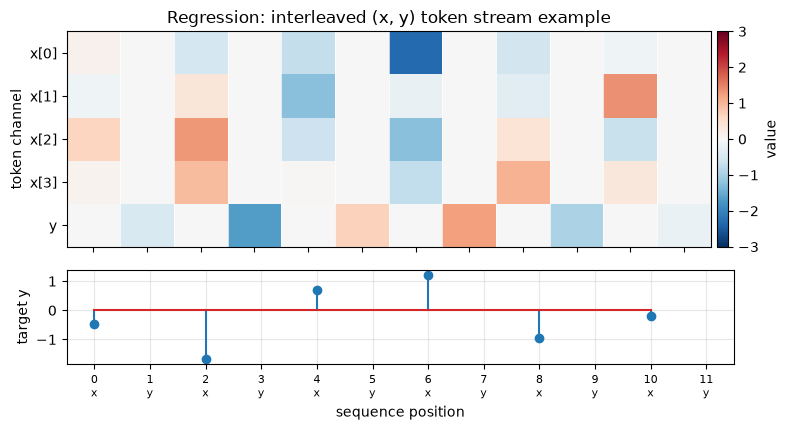

In [8]:
L, D = inputs.shape[1], inputs.shape[2]
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4.4),
                               gridspec_kw={"height_ratios": [3, 1.3]}, sharex=True)

im = ax0.imshow(inputs[0].T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
for t in range(1, L):
    ax0.axvline(t - 0.5, color="w", lw=0.5)
ax0.set_yticks(range(D))
ax0.set_yticklabels([f"x[{i}]" for i in range(d)] + ["y"])
ax0.set_ylabel("token channel")
ax0.set_title("Regression: interleaved (x, y) token stream example")
fig.colorbar(im, ax=ax0, fraction=0.025, pad=0.01, label="value")

qpos = np.where(mask[0])[0]
ax1.stem(qpos, targets[0, qpos])
ax1.set_xticks(range(L))
ax1.set_xticklabels([f"{t}\n{'x' if mask[0, t] else 'y'}" for t in range(L)], fontsize=8)
ax1.set_ylabel("target y")
ax1.set_xlabel("sequence position")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/regression_1.png", dpi=600)
plt.show()


## 1b · Regression difficulty knobs: noise & drift

The regression generator has two knobs that turn the clean task into the *honest* one (swept in `02_noisy_drifting_regression.ipynb`):

- **`noise`** — adds Gaussian label noise `y = W·x + ε`, `ε ~ N(0, noise²)`. The targets shift off the noise-free value, so held-out MSE can no longer reach 0 — it bottoms out at the irreducible floor `σ² = noise²`.
- **`drift`** — makes the ground-truth map `W` take a small random-walk step each example, renormalized to fixed norm (so `W` *rotates* rather than grows; `drift=0` is static). No single `W` explains the whole sequence, so fitting all history becomes sub-optimal and *forgetting* recent-vs-stale evidence starts to matter.

Both are inspected below with **no model** — just the data.

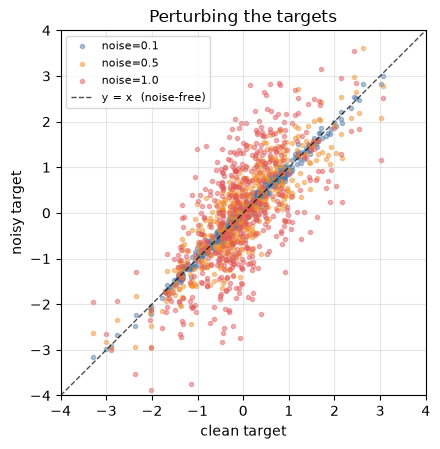

In [14]:
# NOISE: same seed -> identical x and W; only the targets y shift by ~N(0, noise^2).
d_, n_ = 4, 64
_, y_clean, msk = make_regression(batch=8, n_examples=n_, d=d_, noise=0.0, seed=SEED)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
for noise, color in zip([0.1, 0.5, 1.0], ["#4e79a7", "#f28e2b", "#e15759"]):
    _, y_noisy, _ = make_regression(batch=8, n_examples=n_, d=d_, noise=noise, seed=SEED)
    c, ny = y_clean[msk], y_noisy[msk]
    ax.scatter(c, ny, s=9, alpha=0.45, color=color,
               label=f"noise={noise}")
lim = 4.0
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.7, label="y = x  (noise-free)")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("clean target")
ax.set_ylabel("noisy target")
ax.set_title("Perturbing the targets")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)
plt.savefig("figures/regression_4.png", dpi=600)
plt.tight_layout(); plt.show()

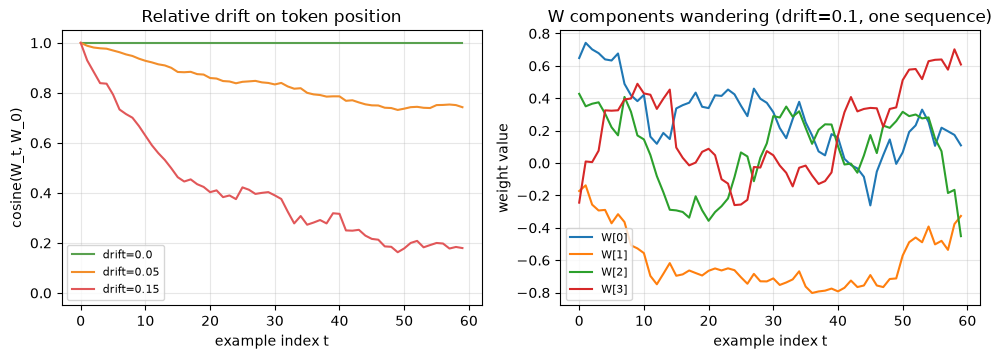

In [11]:
# DRIFT moves the ground-truth map W. Expose W per example (return_weights=True) and
# show it rotating away from its start (cosine to W_0) as drift grows; right: the raw
# components of W wandering across one sequence.
d_, n_ = 4, 60
pos = np.arange(n_)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.0, 3.7))

for drift, color in zip([0.0, 0.05, 0.15], ["#59a14f", "#f28e2b", "#e15759"]):
    *_, W = make_regression(batch=64, n_examples=n_, d=d_, noise=0.0, drift=drift,
                            seed=SEED, return_weights=True)
    W0 = W[:, :1, :]
    cos = (W * W0).sum(-1) / (np.linalg.norm(W, axis=-1) * np.linalg.norm(W0, axis=-1) + 1e-9)
    axL.plot(pos, cos.mean(0), color=color, label=f"drift={drift}")
axL.set_ylim(-0.05, 1.05)
axL.set_xlabel("example index t"); axL.set_ylabel("cosine(W_t, W_0)")
axL.set_title("Relative drift on token position")
axL.legend(fontsize=8); axL.grid(True, alpha=0.3)

*_, W = make_regression(batch=1, n_examples=n_, d=d_, noise=0.0, drift=0.1,
                        seed=SEED, return_weights=True)
for j in range(d_):
    axR.plot(pos, W[0, :, j], label=f"W[{j}]")
axR.set_xlabel("example index t"); axR.set_ylabel("weight value")
axR.set_title("W components wandering (drift=0.1, one sequence)")
axR.legend(fontsize=8); axR.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2 · Multi-query associative recall (MQAR)

Integer token-id stream (`id 0` reserved as blank/filler):

```
[k0 v0 k1 v1 …]   [0 × gap]   [q0 q1 …]
 \— write block —/  \— gap —/  \— queries —/
```

Each query repeats one of the stored keys; the target at that position is the value bound to it. Keys within a sequence are distinct, so recall is unambiguous. Only the query positions are scored.

In [5]:
n_pairs, n_queries, gap, vocab = 4, 3, 3, 12
mq_in, mq_tg, mq_mask = make_mqar(
    batch=4, n_pairs=n_pairs, n_queries=n_queries, gap=gap, vocab=vocab, seed=SEED)

print(f"inputs {mq_in.shape}  targets {mq_tg.shape}  mask {mq_mask.shape}   (id 0 = blank filler)")
print("\nExample 0:")
print("  tokens :", mq_in[0].tolist())
print("  target :", mq_tg[0].tolist())
print("  mask   :", mq_mask[0].astype(int).tolist())
bindings = {int(mq_in[0, 2*i]): int(mq_in[0, 2*i+1]) for i in range(n_pairs)}
print("\n  writes (key -> value):", bindings)
for p in np.where(mq_mask[0])[0]:
    print(f"  query @pos {p:2d}: key {int(mq_in[0, p])} -> expected value {int(mq_tg[0, p])}")

inputs (4, 14)  targets (4, 14)  mask (4, 14)   (id 0 = blank filler)

Example 0:
  tokens : [3, 1, 10, 2, 7, 9, 6, 8, 0, 0, 0, 6, 7, 7]
  target : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 9, 9]
  mask   : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]

  writes (key -> value): {3: 1, 10: 2, 7: 9, 6: 8}
  query @pos 11: key 6 -> expected value 8
  query @pos 12: key 7 -> expected value 9
  query @pos 13: key 7 -> expected value 9


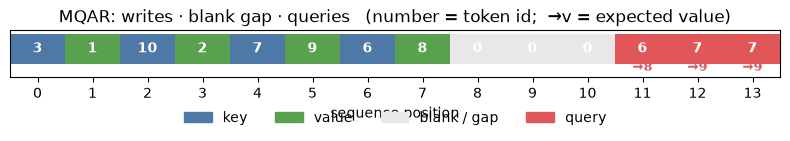

In [6]:
L = mq_in.shape[1]
q_start = 2 * n_pairs + gap

role = np.zeros(L, dtype=int)          # 0 blank, 1 key, 2 value, 3 query
role[0:2 * n_pairs:2] = 1
role[1:2 * n_pairs:2] = 2
role[q_start:q_start + n_queries] = 3

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 2.0))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(L):
    ax.text(t, 0, str(int(mq_in[0, t])), ha="center", va="center",
            color="white", fontweight="bold")
    if mq_mask[0, t]:
        ax.text(t, 0.62, f"\u2192{int(mq_tg[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=9, fontweight="bold")
ax.set_ylim(0.95, -0.6)
ax.set_yticks([])
ax.set_xticks(range(L))
ax.set_xlabel("sequence position")
ax.set_title("MQAR: writes \u00b7 blank gap \u00b7 queries   (number = token id;  \u2192v = expected value)")
handles = [Patch(color="#4e79a7", label="key"), Patch(color="#59a14f", label="value"),
           Patch(color="#e8e8e8", label="blank / gap"), Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.45), frameon=False)
plt.tight_layout()
plt.show()

### Capacity pressure — what a large `n_pairs` looks like

`n_pairs` is the memory-load knob. Above it was tiny (4 bindings); the recall experiment (`03_mqar_capacity.ipynb`) pushes it *toward and past* the layer's effective key dimension so the fixed-size recurrent state can no longer hold every binding without interference. The data stays unambiguous — keys are always distinct — so any failure to recall is the **model's** capacity limit, not the task's. Below is the same picture at a much larger `n_pairs`: the write block dominates the sequence and many keys must be packed into one state before the queries arrive.

In [ ]:
big_pairs, big_queries, big_gap, big_vocab = 16, 4, 6, 64
bg_in, bg_tg, bg_mask = make_mqar(
    batch=4, n_pairs=big_pairs, n_queries=big_queries, gap=big_gap, vocab=big_vocab, seed=SEED)
Lb = bg_in.shape[1]
qb_start = 2 * big_pairs + big_gap
print(f"inputs {bg_in.shape}   write block = {2*big_pairs} tokens ({big_pairs} bindings), "
      f"gap = {big_gap}, queries = {big_queries}  ->  L = {Lb}")

role = np.zeros(Lb, dtype=int)             # 0 blank, 1 key, 2 value, 3 query
role[0:2 * big_pairs:2] = 1
role[1:2 * big_pairs:2] = 2
role[qb_start:qb_start + big_queries] = 3

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(11, 1.9))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(Lb):
    ax.text(t, 0, str(int(bg_in[0, t])), ha="center", va="center",
            color="white", fontsize=7, fontweight="bold")
    if bg_mask[0, t]:
        ax.text(t, 0.7, f"→{int(bg_tg[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=8, fontweight="bold")
ax.axvline(2 * big_pairs - 0.5, color="k", lw=1.2, ls=":")     # write | gap boundary
ax.axvline(qb_start - 0.5, color="k", lw=1.2, ls=":")          # gap | query boundary
ax.set_ylim(1.05, -0.7)
ax.set_yticks([])
ax.set_xticks(range(0, Lb, 2))
ax.set_xlabel("sequence position")
ax.set_title(f"MQAR under capacity pressure: {big_pairs} bindings must be packed into one "
             f"fixed state before {big_queries} queries arrive")
handles = [Patch(color="#4e79a7", label="key"), Patch(color="#59a14f", label="value"),
           Patch(color="#e8e8e8", label="blank / gap"), Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=4, loc="upper center",
          bbox_to_anchor=(0.5, -0.5), frameon=False)
plt.tight_layout()
plt.show()

### Distractors — interference in the gap

The `n_distractors` knob writes extra key→value pairs that are **never queried** and whose keys are **disjoint** from the target keys, placed *after* the target block (so they are the most-recent bindings before the queries). They are pure interference: a single-step read-out can be overwritten by these recent competitors, while an exact full-history solve can deconvolve them. Because the distractors are *newer* than the targets, **forgetting (recency bias) hurts here** — the opposite of the drift task — so this is the recall setting in which sweeping the forget gate finally has teeth. The data stays unambiguous: queries only ask about target keys.

In [ ]:
dp, dq, dgap, dvocab, ndist = 4, 3, 2, 24, 4
di, dt, dm = make_mqar(batch=4, n_pairs=dp, n_queries=dq, gap=dgap, vocab=dvocab,
                       seed=SEED, n_distractors=ndist)
Ld = di.shape[1]
ds_start = 2 * dp                       # distractor block start
dq_start = 2 * dp + 2 * ndist + dgap    # query block start
print(f"inputs {di.shape}   targets={dp} ({2*dp} tok) · distractors={ndist} ({2*ndist} tok) · "
      f"gap={dgap} · queries={dq}  ->  L={Ld}")
print("  target writes (queryable)        :",
      {int(di[0, 2*i]): int(di[0, 2*i+1]) for i in range(dp)})
print("  distractor writes (NEVER queried):",
      {int(di[0, ds_start+2*i]): int(di[0, ds_start+2*i+1]) for i in range(ndist)})

role = np.zeros(Ld, dtype=int)          # 0 blank,1 key,2 value,3 distractor,4 query
role[0:2*dp:2] = 1
role[1:2*dp:2] = 2
role[ds_start:ds_start+2*ndist] = 3
role[dq_start:dq_start+dq] = 4

cmap = ListedColormap(["#e8e8e8", "#4e79a7", "#59a14f", "#edc948", "#e15759"])
norm = BoundaryNorm([-.5, .5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 1.9))
ax.imshow(role[None, :], aspect="auto", cmap=cmap, norm=norm)
for t in range(Ld):
    ax.text(t, 0, str(int(di[0, t])), ha="center", va="center",
            color="black" if role[t] == 3 else "white", fontsize=8, fontweight="bold")
    if dm[0, t]:
        ax.text(t, 0.68, f"→{int(dt[0, t])}", ha="center", va="center",
                color="#e15759", fontsize=9, fontweight="bold")
ax.axvline(ds_start - 0.5, color="k", lw=1.2, ls=":")            # targets | distractors
ax.axvline(dq_start - 0.5, color="k", lw=1.2, ls=":")            # gap | queries
ax.set_ylim(1.0, -0.7); ax.set_yticks([]); ax.set_xticks(range(Ld))
ax.set_xlabel("sequence position")
ax.set_title("MQAR with distractors: targets · distractors (never queried) · gap · queries")
handles = [Patch(color="#4e79a7", label="target key"), Patch(color="#59a14f", label="target value"),
           Patch(color="#edc948", label="distractor k/v"), Patch(color="#e8e8e8", label="blank / gap"),
           Patch(color="#e15759", label="query")]
ax.legend(handles=handles, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.5),
          frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 3 · Running parity

Random bits in `{0, 1}`; the target at position `t` is the running parity `cumsum(bits[0..t]) mod 2`. **Every** position is scored (mask all-True). This is the minimal long-range state-tracking probe — a layer that cannot integrate over the whole prefix fails at the late positions.

In [ ]:
seq_len = 16
p_in, p_tg, p_mask = make_parity(batch=4, seq_len=seq_len, seed=SEED)

print(f"inputs {p_in.shape}  targets {p_tg.shape}  mask {p_mask.shape}   (every position scored)")
print("\nExample 0:")
print("  bits   :", p_in[0].tolist())
print("  parity :", p_tg[0].tolist(), "  (running #1s mod 2)")
print("  cumsum :", np.cumsum(p_in[0]).tolist())

inputs (4, 16)  targets (4, 16)  mask (4, 16)   (every position scored)

Example 0:
  bits   : [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
  parity : [1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0]   (running #1s mod 2)
  cumsum : [1, 2, 3, 3, 3, 3, 3, 3, 3, 4, 5, 6, 7, 8, 9, 10]


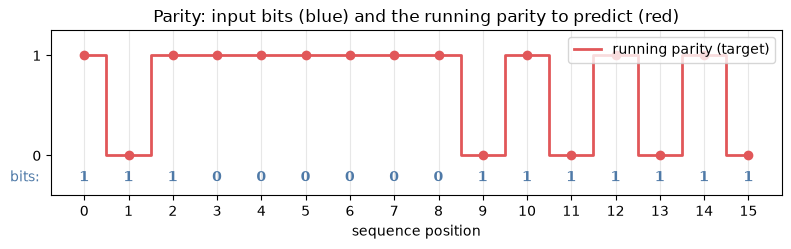

In [ ]:
pos = np.arange(seq_len)
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.step(pos, p_tg[0], where="mid", color="#e15759", lw=2, label="running parity (target)")
ax.scatter(pos, p_tg[0], color="#e15759", zorder=3)
for t in pos:
    ax.text(t, -0.22, str(int(p_in[0, t])), ha="center", va="center",
            color="#4e79a7", fontweight="bold")
ax.text(-1.0, -0.22, "bits:", ha="right", va="center", color="#4e79a7")
ax.set_yticks([0, 1])
ax.set_ylim(-0.4, 1.25)
ax.set_xticks(pos)
ax.set_xlabel("sequence position")
ax.set_title("Parity: input bits (blue) and the running parity to predict (red)")
ax.legend(loc="upper right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Next

These encodings are exactly what the comparison notebooks feed to the `flash-linear-attention` layers (after a learned input projection). Continue to **`01_regression_sanity.ipynb`** for the first MesaNet-vs-Gated-DeltaNet comparison and the CG-semantics correctness check.